# TASK 6 — Netflix Business Insights Report

Task Requirements

Complete exploratory data analysis , 
Identify important content trends and patterns , 
Develop multiple visualizations , 
Generate actionable business insights , 
Prepare a final analytical report.

In [26]:
%pip install seaborn
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [29]:
# loading the cleaned Netflix dataset

df = pd.read_csv("Netflix_Cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head(5)

Dataset loaded successfully!
Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_month_name,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,90.0
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,1.0
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,125.0


In [30]:
# checking dataset information

print("=" * 60)
print("              DATASET INFORMATION")
print("=" * 60)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

              DATASET INFORMATION

Number of Rows: 8790
Number of Columns: 14

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'date_added_year', 'date_added_month', 'date_added_month_name', 'duration_value']

Data Types:
show_id                      str
type                         str
title                        str
director                     str
country                      str
date_added                   str
release_year               int64
rating                       str
duration                     str
listed_in                    str
date_added_year            int64
date_added_month           int64
date_added_month_name        str
duration_value           float64
dtype: object


In [31]:
# checking missing values

missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
show_id                  0
type                     0
title                    0
director                 0
country                  0
date_added               0
release_year             0
rating                   0
duration                 0
listed_in                0
date_added_year          0
date_added_month         0
date_added_month_name    0
duration_value           0
dtype: int64


In [32]:
# displaying only columns with missing values

missing_summary = (
    df.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = [
    "Column",
    "Missing_Values"
]

missing_summary = missing_summary[
    missing_summary["Missing_Values"] > 0
]

missing_summary

,Column,Missing_Values


In [33]:
# calculating content type distribution

content_counts = df["type"].value_counts()

print("Content Type Distribution:")
print(content_counts)

Content Type Distribution:
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


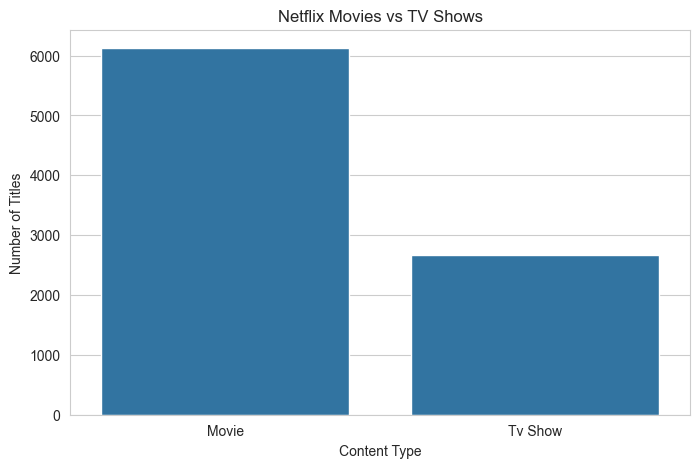

In [34]:
# visualizing content type distribution

plt.figure(figsize=(8, 5))

sns.barplot(
    x=content_counts.index,
    y=content_counts.values
)

plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [35]:
# calculating content type percentages

content_percentage = (
    df["type"]
    .value_counts(normalize=True) * 100
)

print("Content Type Percentage:")
print(content_percentage.round(2))

Content Type Percentage:
type
Movie      69.69
Tv Show    30.31
Name: proportion, dtype: float64


In [36]:
# preparing country information

country_df = df.copy()

country_df["country"] = (
    country_df["country"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
)

country_df = country_df.explode("country")

country_df["country"] = (
    country_df["country"]
    .str.strip()
)

country_counts = country_df["country"].value_counts()

print("Top 10 Countries:")
print(country_counts.head(10))

Top 10 Countries:
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64


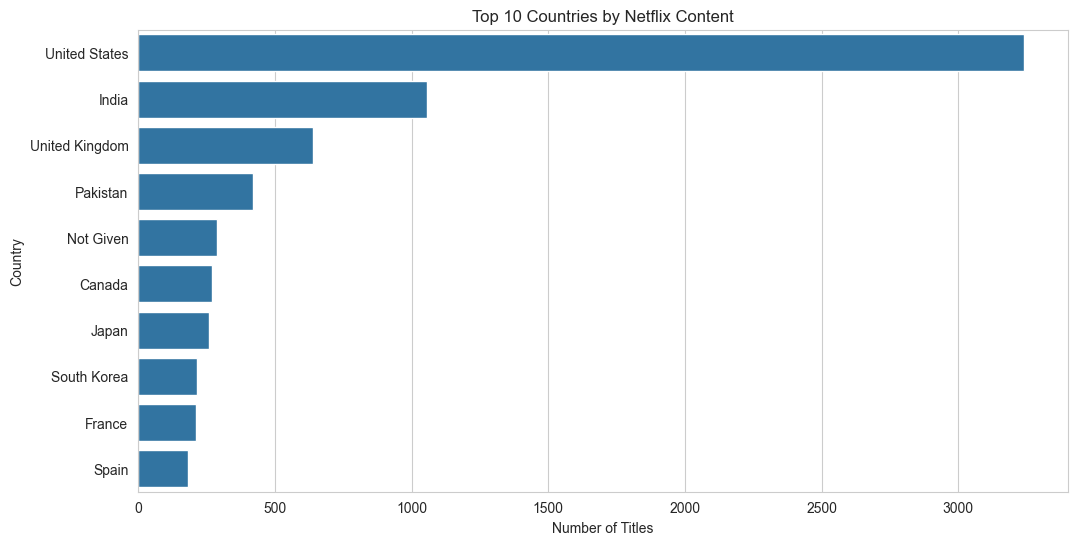

In [37]:
# visualizing top content-producing countries

top_countries = country_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.show()

In [38]:
# calculating yearly content releases

year_counts = (
    df["release_year"]
    .value_counts()
    .sort_index()
)

year_analysis = year_counts.reset_index()

year_analysis.columns = [
    "Release_Year",
    "Content_Count"
]

year_analysis.head()

,Release_Year,Content_Count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


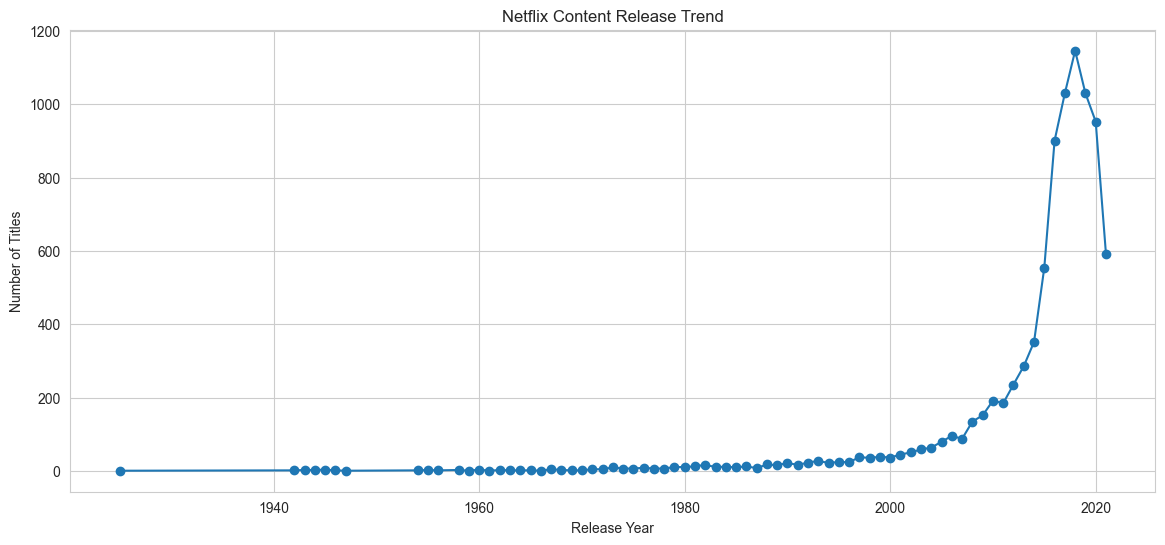

In [39]:
# visualizing Netflix content release trend

plt.figure(figsize=(14, 6))

plt.plot(
    year_analysis["Release_Year"],
    year_analysis["Content_Count"],
    marker="o"
)

plt.title("Netflix Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

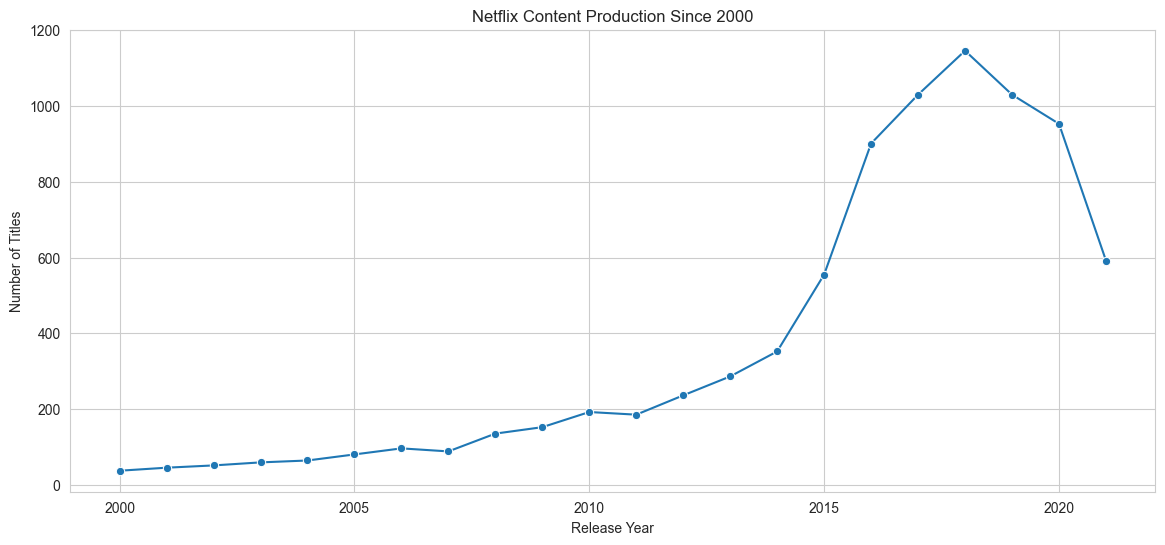

In [40]:
# analyzing recent content production

recent_years = year_analysis[
    year_analysis["Release_Year"] >= 2000
]

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=recent_years,
    x="Release_Year",
    y="Content_Count",
    marker="o"
)

plt.title("Netflix Content Production Since 2000")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [41]:
# calculating rating distribution

rating_counts = df["rating"].value_counts()

print("Rating Distribution:")
print(rating_counts)

Rating Distribution:
rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


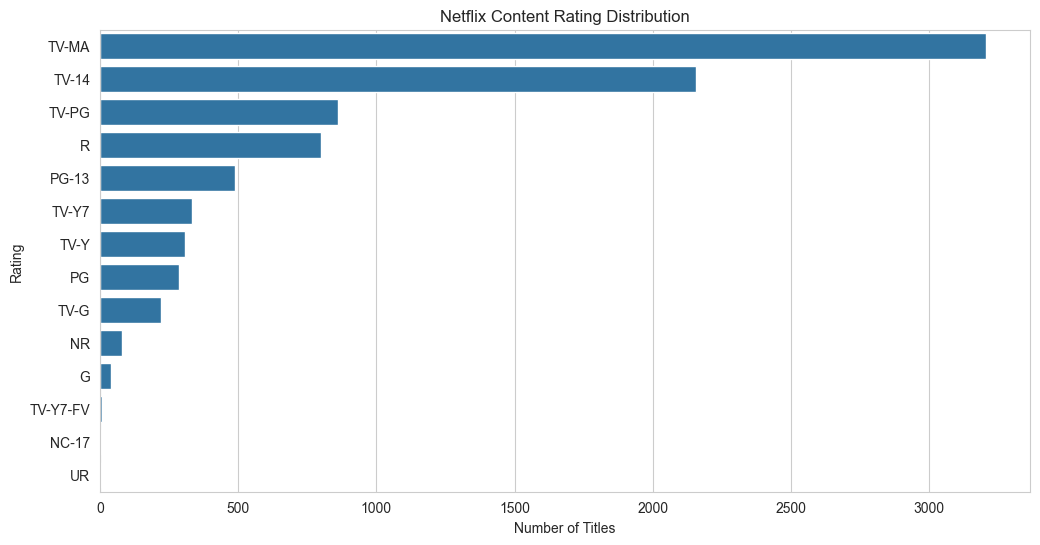

In [42]:
# visualizing rating distribution

plt.figure(figsize=(12, 6))

sns.barplot(
    x=rating_counts.values,
    y=rating_counts.index
)

plt.title("Netflix Content Rating Distribution")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [43]:
# preparing genre information

genre_df = df.copy()

genre_df["listed_in"] = (
    genre_df["listed_in"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
)

genre_df = genre_df.explode("listed_in")

genre_df["listed_in"] = (
    genre_df["listed_in"]
    .str.strip()
)

genre_counts = genre_df["listed_in"].value_counts()

print("Top 15 Genres:")
print(genre_counts.head(15))

Top 15 Genres:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  573
Crime TV Shows               469
Kids' TV                     448
Docuseries                   394
Name: count, dtype: int64


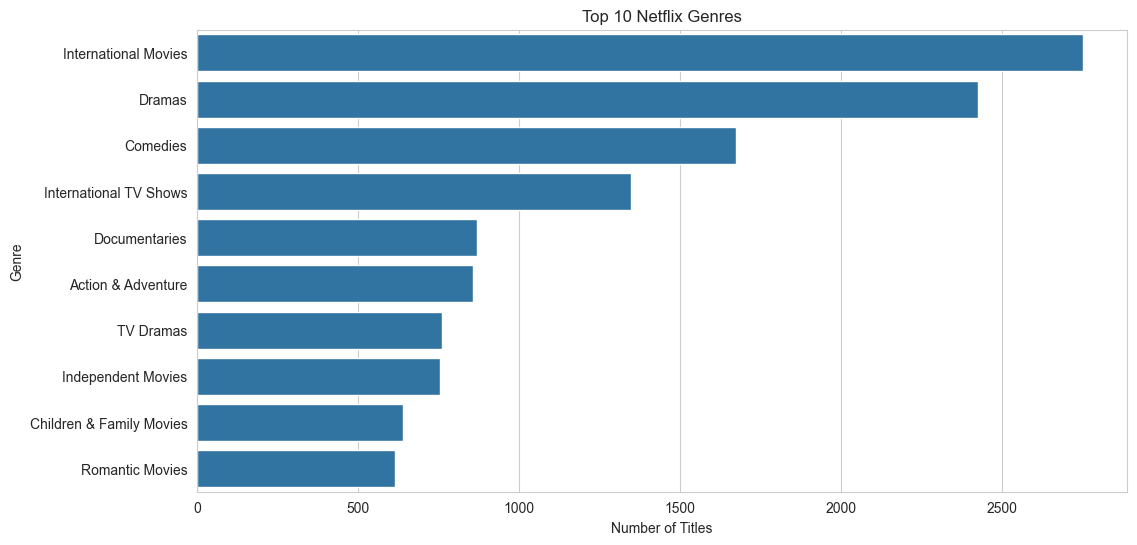

In [44]:
# visualizing top 10 genres

top_genres = genre_counts.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [45]:
# calculating yearly content by type

year_type = (
    df.groupby(["release_year", "type"])
    .size()
    .reset_index(name="Number_of_Titles")
)

recent_year_type = year_type[
    year_type["release_year"] >= 2000
]

recent_year_type.head()

,release_year,type,Number_of_Titles
75,2000,Movie,33
76,2000,Tv Show,4
77,2001,Movie,40
78,2001,Tv Show,5
79,2002,Movie,44


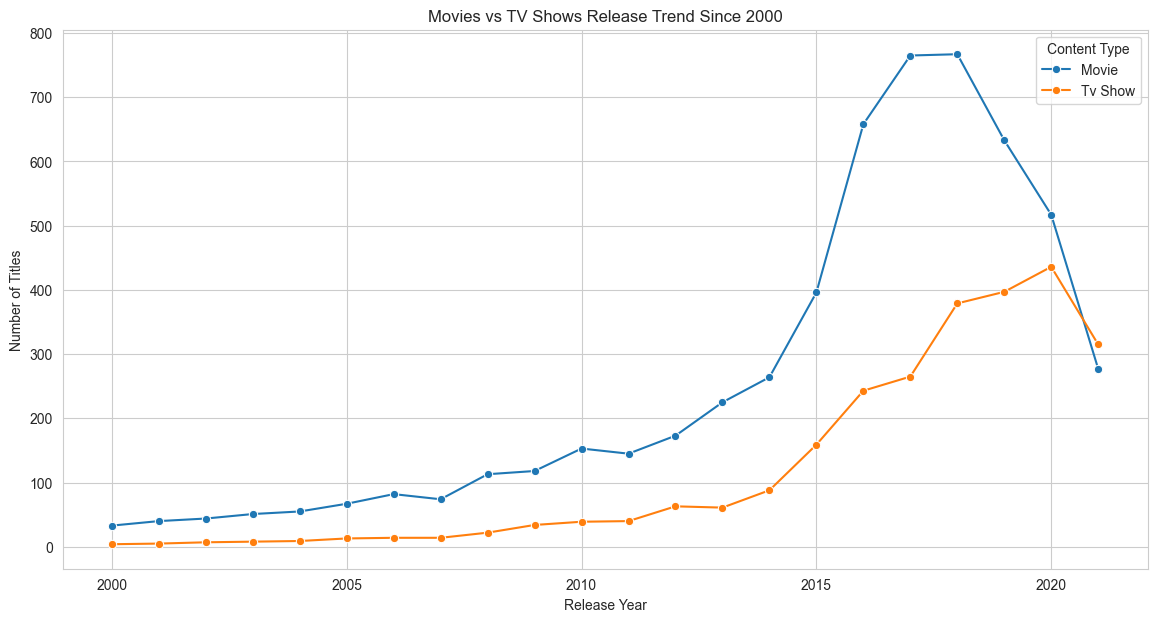

In [46]:
# visualizing Movies vs TV Shows over time

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=recent_year_type,
    x="release_year",
    y="Number_of_Titles",
    hue="type",
    marker="o"
)

plt.title("Movies vs TV Shows Release Trend Since 2000")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.legend(title="Content Type")

plt.show()

In [47]:
# calculating key business metrics

total_titles = len(df)

total_movies = (
    df["type"] == "Movie"
).sum()

total_tv_shows = (
    df["type"] == "TV Show"
).sum()

total_countries = country_counts[
    country_counts.index != "Unknown"
].shape[0]

total_genres = genre_counts[
    genre_counts.index != "Unknown"
].shape[0]

most_common_rating = rating_counts.idxmax()
most_common_rating_count = rating_counts.max()

most_common_genre = genre_counts.idxmax()
most_common_genre_count = genre_counts.max()

peak_year = year_counts.idxmax()
peak_year_count = year_counts.max()

top_country = country_counts.index[0]
top_country_count = country_counts.iloc[0]

In [48]:
# displaying key business metrics

print("=" * 65)
print("                 NETFLIX KPI REPORT")
print("=" * 65)

print(f"\nTotal Titles              : {total_titles}")
print(f"Total Movies              : {total_movies}")
print(f"Total TV Shows            : {total_tv_shows}")
print(f"Countries Represented     : {total_countries}")
print(f"Genres Represented        : {total_genres}")

print(f"\nMost Common Rating        : {most_common_rating}")
print(f"Titles with This Rating  : {most_common_rating_count}")

print(f"\nMost Common Genre         : {most_common_genre}")
print(f"Titles in This Genre     : {most_common_genre_count}")

print(f"\nPeak Release Year         : {peak_year}")
print(f"Titles Released That Year: {peak_year_count}")

print(f"\nTop Content Country       : {top_country}")
print(f"Content Count             : {top_country_count}")

                 NETFLIX KPI REPORT

Total Titles              : 8790
Total Movies              : 6126
Total TV Shows            : 0
Countries Represented     : 86
Genres Represented        : 42

Most Common Rating        : TV-MA
Titles with This Rating  : 3205

Most Common Genre         : International Movies
Titles in This Genre     : 2752

Peak Release Year         : 2018
Titles Released That Year: 1146

Top Content Country       : United States
Content Count             : 3240


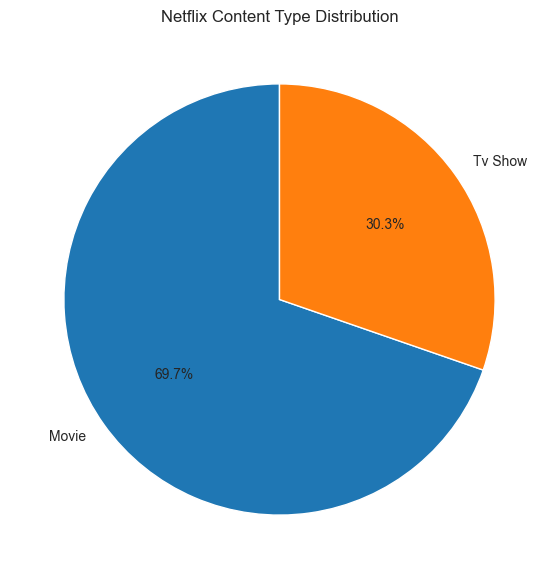

In [49]:
# creating content type distribution chart

plt.figure(figsize=(7, 7))

plt.pie(
    content_counts.values,
    labels=content_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Netflix Content Type Distribution")

plt.show()

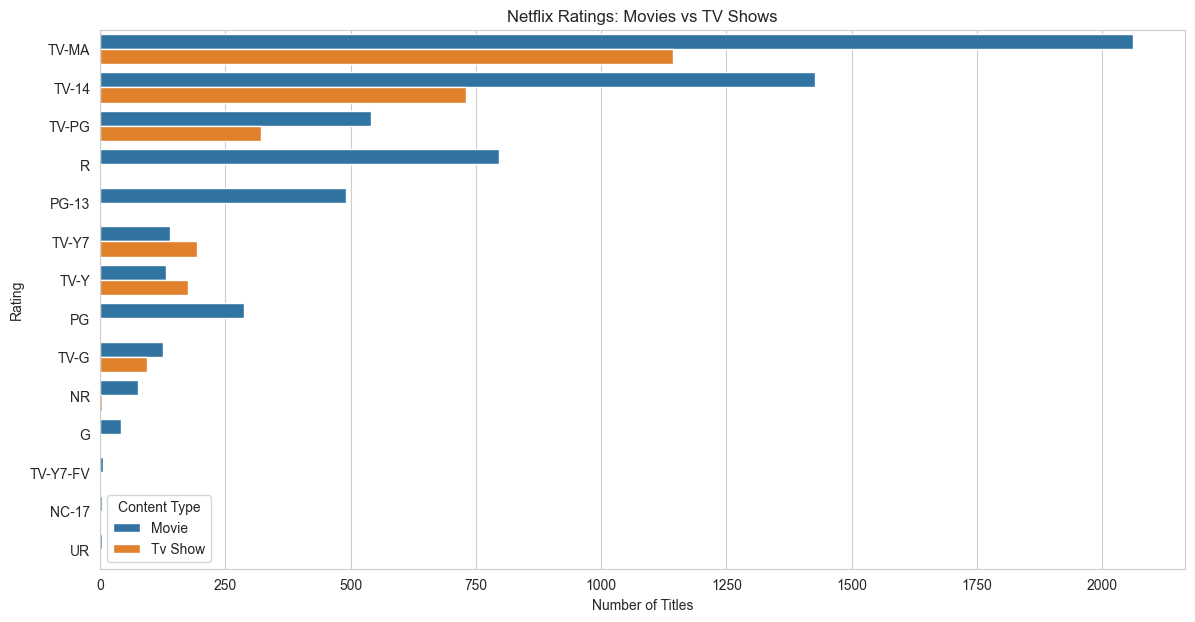

In [50]:
# comparing ratings across Movies and TV Shows

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    y="rating",
    hue="type",
    order=rating_counts.index
)

plt.title("Netflix Ratings: Movies vs TV Shows")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.legend(title="Content Type")

plt.show()

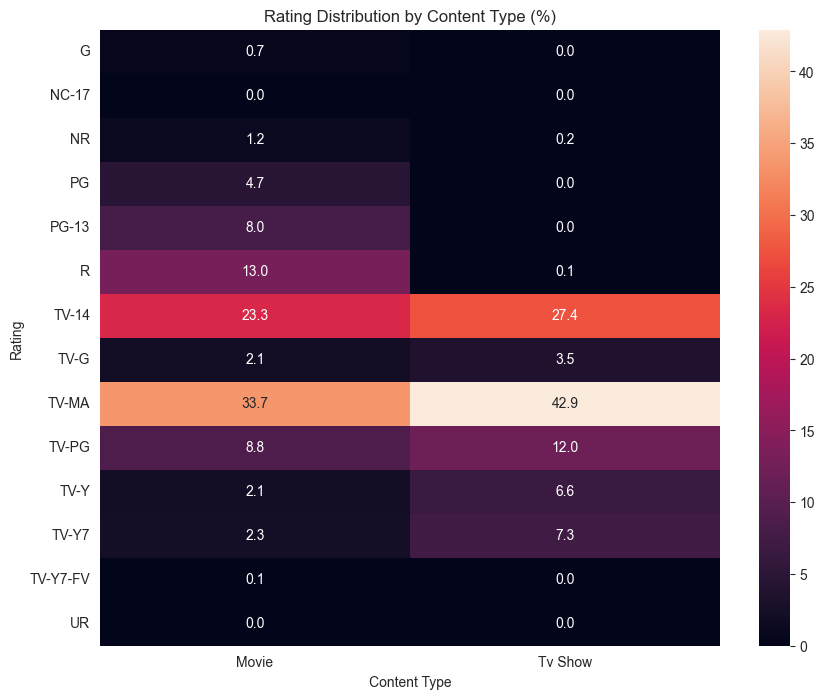

In [51]:
# creating rating percentage heatmap

rating_type_percentage = (
    pd.crosstab(
        df["rating"],
        df["type"],
        normalize="columns"
    ) * 100
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    rating_type_percentage,
    annot=True,
    fmt=".1f"
)

plt.title("Rating Distribution by Content Type (%)")
plt.xlabel("Content Type")
plt.ylabel("Rating")

plt.show()

In [52]:
# generating final business insights

print("=" * 70)
print("              NETFLIX BUSINESS INSIGHTS")
print("=" * 70)

print(
    f"\n1. CONTENT MIX:"
    f"\n   Netflix has {total_movies} Movies and "
    f"{total_tv_shows} TV Shows."
)

if total_movies > total_tv_shows:
    print(
        "   Movies represent the larger share of the "
        "Netflix catalog."
    )
else:
    print(
        "   TV Shows represent the larger share of the "
        "Netflix catalog."
    )


print(
    f"\n2. TOP CONTENT COUNTRY:"
    f"\n   {top_country} is the leading country in terms "
    f"of listed Netflix content."
)


print(
    f"\n3. CONTENT PRODUCTION TREND:"
    f"\n   The peak release year in this dataset is "
    f"{peak_year}, with {peak_year_count} titles."
)


print(
    f"\n4. MOST COMMON RATING:"
    f"\n   {most_common_rating} is the most frequently "
    f"represented rating."
)


print(
    f"\n5. MOST COMMON GENRE:"
    f"\n   {most_common_genre} is the most frequently "
    f"represented genre."
)


print(
    "\n6. CONTENT STRATEGY:"
    "\n   The analysis can help identify major content "
    "categories and geographic markets."
)


print(
    "\n7. AUDIENCE TARGETING:"
    "\n   Rating and genre distributions provide insight "
    "into the audiences targeted by Netflix."
)


print(
    "\n8. BUSINESS DECISION MAKING:"
    "\n   These trends can support decisions about "
    "content investment, regional expansion and "
    "audience-focused programming."
)

              NETFLIX BUSINESS INSIGHTS

1. CONTENT MIX:
   Netflix has 6126 Movies and 0 TV Shows.
   Movies represent the larger share of the Netflix catalog.

2. TOP CONTENT COUNTRY:
   United States is the leading country in terms of listed Netflix content.

3. CONTENT PRODUCTION TREND:
   The peak release year in this dataset is 2018, with 1146 titles.

4. MOST COMMON RATING:
   TV-MA is the most frequently represented rating.

5. MOST COMMON GENRE:
   International Movies is the most frequently represented genre.

6. CONTENT STRATEGY:
   The analysis can help identify major content categories and geographic markets.

7. AUDIENCE TARGETING:
   Rating and genre distributions provide insight into the audiences targeted by Netflix.

8. BUSINESS DECISION MAKING:
   These trends can support decisions about content investment, regional expansion and audience-focused programming.


In [53]:
# creating final summary report

final_summary = pd.DataFrame({
    "Metric": [
        "Total Titles",
        "Total Movies",
        "Total TV Shows",
        "Countries",
        "Genres",
        "Most Common Rating",
        "Most Common Genre",
        "Peak Release Year",
        "Top Content Country"
    ],
    
    "Value": [
        total_titles,
        total_movies,
        total_tv_shows,
        total_countries,
        total_genres,
        most_common_rating,
        most_common_genre,
        peak_year,
        top_country
    ]
})

final_summary

,Metric,Value
0,Total Titles,8790
1,Total Movies,6126
2,Total TV Shows,0
3,Countries,86
4,Genres,42
5,Most Common Rating,TV-MA
6,Most Common Genre,International Movies
7,Peak Release Year,2018
8,Top Content Country,United States


In [54]:
# exporting final business report

final_summary.to_csv(
    "Netflix_Business_Insights_Report.csv",
    index=False
)

print("Final business insights report saved successfully!")
print("File: Netflix_Business_Insights_Report.csv")

Final business insights report saved successfully!
File: Netflix_Business_Insights_Report.csv


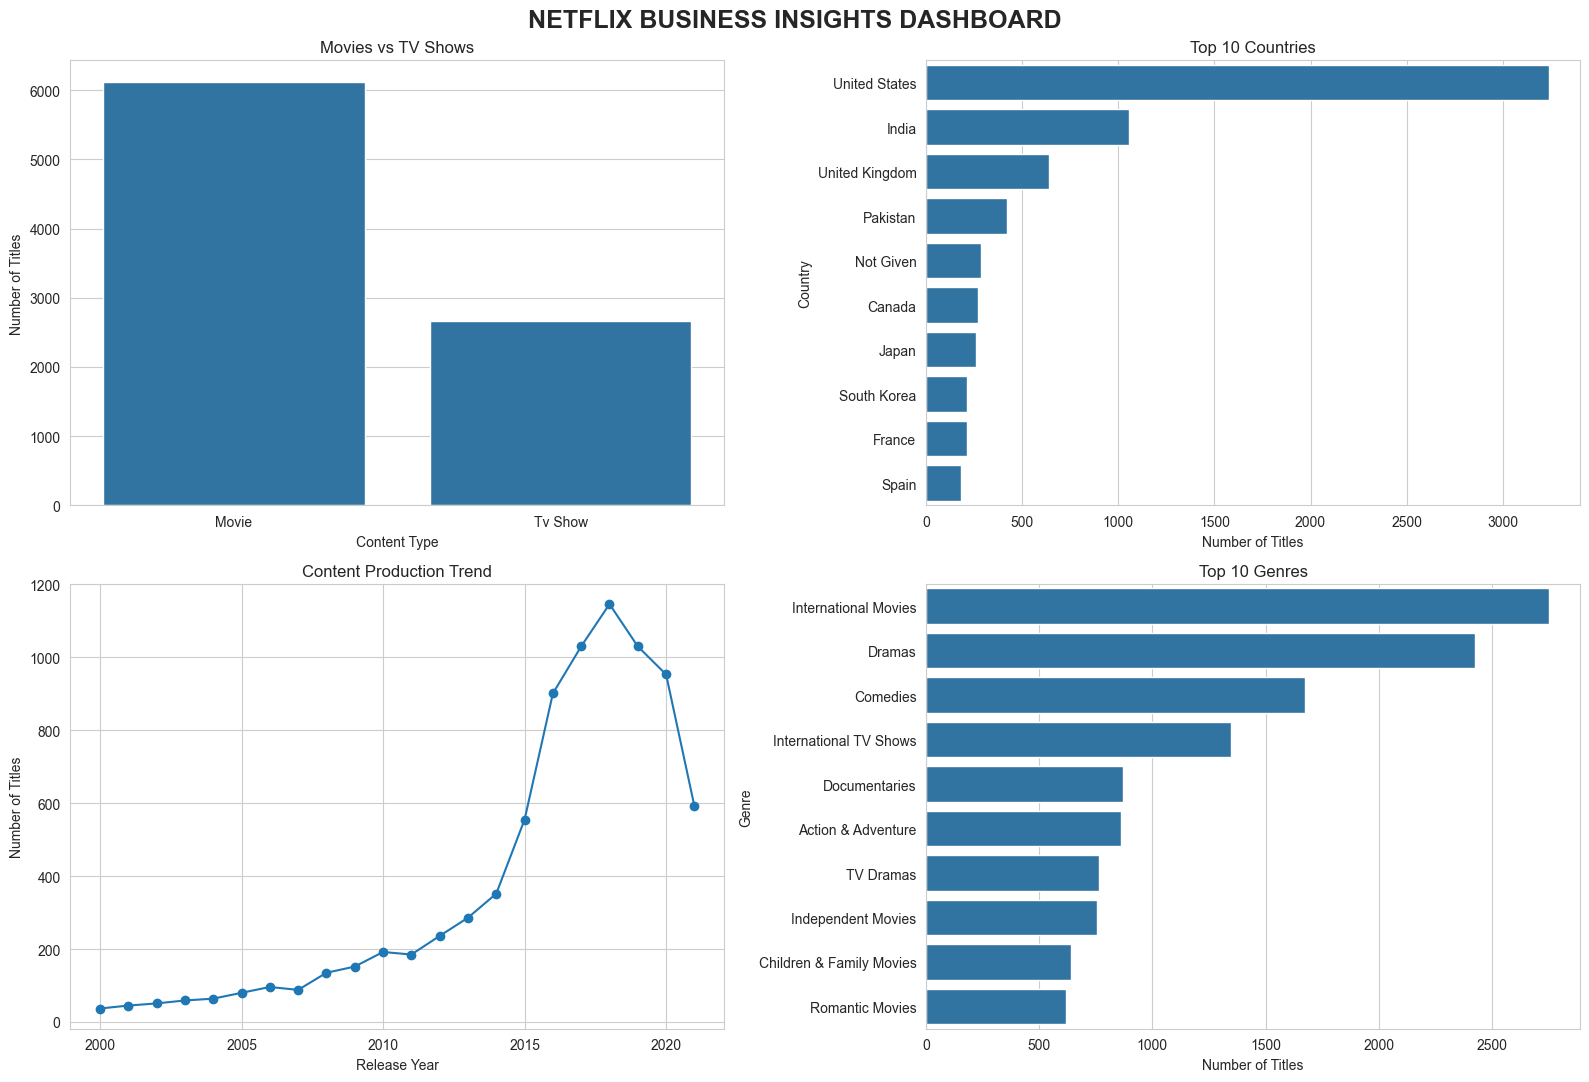

In [55]:
# creating a Netflix business dashboard

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ------------------------------------------
# Chart 1 - Content Type
# ------------------------------------------

sns.barplot(
    x=content_counts.index,
    y=content_counts.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Movies vs TV Shows")
axes[0, 0].set_xlabel("Content Type")
axes[0, 0].set_ylabel("Number of Titles")


# ------------------------------------------
# Chart 2 - Top Countries
# ------------------------------------------

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Top 10 Countries")
axes[0, 1].set_xlabel("Number of Titles")
axes[0, 1].set_ylabel("Country")


# ------------------------------------------
# Chart 3 - Release Trend
# ------------------------------------------

axes[1, 0].plot(
    recent_years["Release_Year"],
    recent_years["Content_Count"],
    marker="o"
)

axes[1, 0].set_title("Content Production Trend")
axes[1, 0].set_xlabel("Release Year")
axes[1, 0].set_ylabel("Number of Titles")


# ------------------------------------------
# Chart 4 - Top Genres
# ------------------------------------------

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Top 10 Genres")
axes[1, 1].set_xlabel("Number of Titles")
axes[1, 1].set_ylabel("Genre")


plt.suptitle(
    "NETFLIX BUSINESS INSIGHTS DASHBOARD",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()